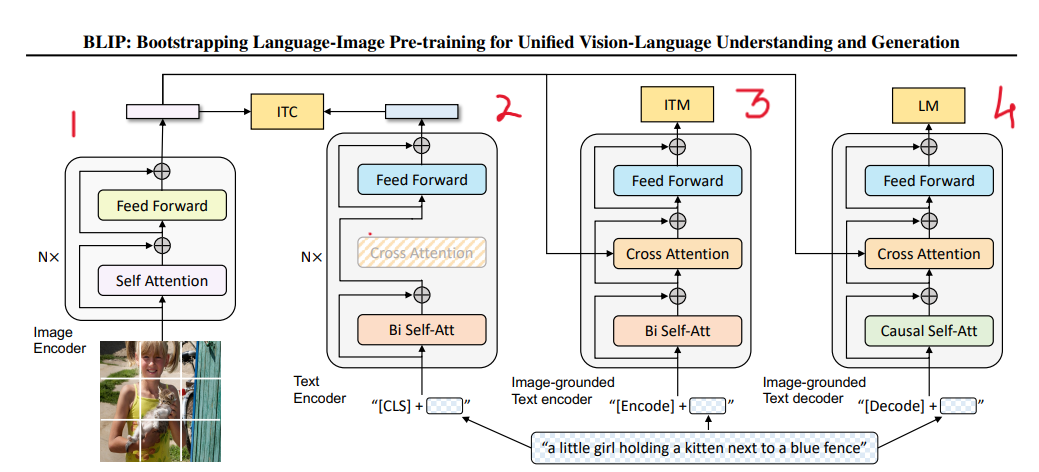

For Image data they used one encoder marked by '1' in image.

Image Encoder (A vision transformer) - Which divides an input image into
patches and encodes them as a sequence of embeddings,
with an additional [CLS] token to represent the global image feature. 

Implementation already done from scratch , github link-(https://github.com/Atharva-Gaykar/Deep_Learning/blob/main/VIT/Vision_Transformer_Scratch.ipynb)


For  text data they used two encoders Image grounded Text encoder marked by '3' and Unimodal (Text only) encoder marked by '2'.

Image Grounded Text decoder marked by '4'.

(1) Unimodal encoder, which separately encodes image
and text. The text encoder is the same as BERT (Devlin et al.,
2019), where a [CLS] token is appended to the beginning
of the text input to summarize the sentence.


(2) Image-grounded text encoder, which injects visual
information by inserting one additional cross-attention (CA)
layer between the self-attention (SA) layer and the feed
forward network (FFN) for each transformer block of the
text encoder. A task-specific [Encode] token is appended
to the text, and the output embedding of [Encode] is used
as the multimodal representation of the image-text pair.


(3) Image-grounded text decoder, which replaces the bidirectional self-attention layers in the image-grounded text
encoder with causal self-attention layers. A [Decode]
token is used to signal the beginning of a sequence, and an
end-of-sequence token is used to signal its end.


The cross attention is similar to the self attention the only difference is that the query comes from the imput end for example in machine translation the query comes from the 
encoder side. In BLIP case the query part comes from Image encoder marked by '1'.

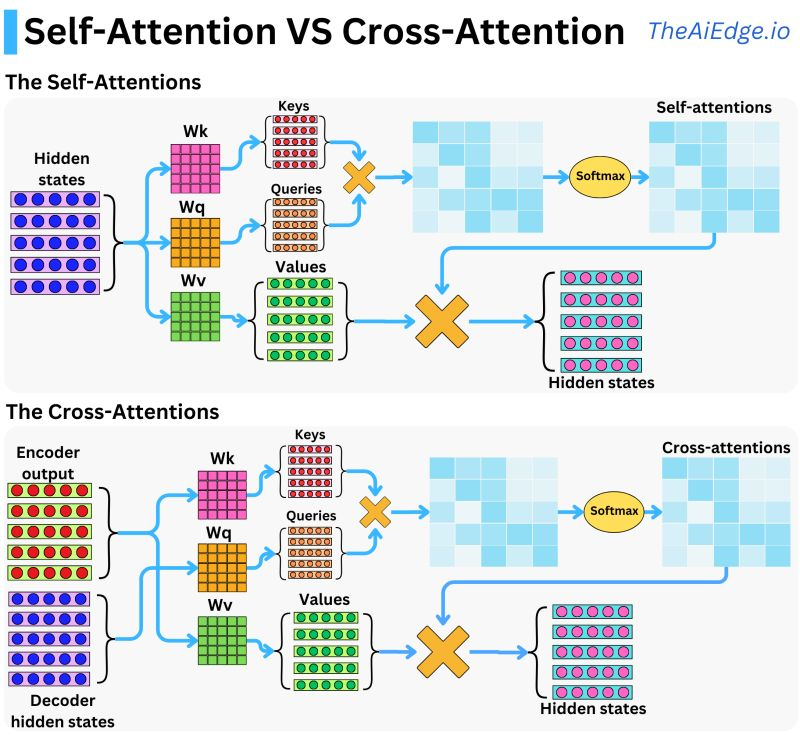

LM above language model loss (Cross entropy) ,this approach is similar to decoder only model like gpt2 (already implemented from scratch github link-(https://github.com/Atharva-Gaykar/Deep_Learning/blob/main/GPT2/LM_GPT2_SCRATCH.ipynb)).


Language Modeling Loss (LM) activates the imagegrounded text decoder, which aims to generate textual descriptions given an image. It optimizes a cross entropy loss
which trains the model to maximize the likelihood of the
text in an autoregressive manner. We apply a label smoothing of 0.1 when computing the loss. Compared to the MLM
loss that has been widely-used for VLP, LM enables the
model with the generalization capability to convert visual
information into coherent captions.


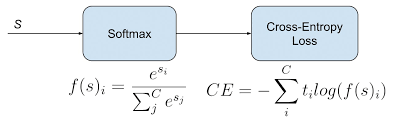

Image-Text Matching Loss (ITM) activates the imagegrounded text encoder. It aims to learn image-text multimodal representation that captures the fine-grained alignment between vision and language. ITM is a binary classification task, where the model uses an ITM head (a linear layer) to predict whether an image-text pair is positive
(matched) or negative (unmatched) given their multimodal
feature

Image grounded text encoder (marked by '3') is trained using ITM Loss.

As ITM is binary classification task the loss function used is Binary Cross Entropy.

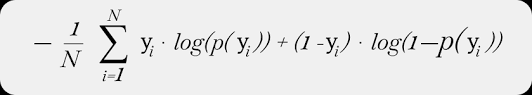

Here p(yi) denotes the predicted probability by the model  yi denotes the correct probability.

In order to find more informative negatives, researchers used
adopt the hard negative mining strategy by Li et al. (2021a),
where negatives pairs with higher contrastive similarity in a
batch are more likely to be selected to compute the loss.



---
what is negative mining?
- In tasks like ITM, the model learns by comparing **positive pairs** (correct image–caption matches) and **negative pairs** (mismatched image–caption pairs).
- **Naïve negatives**: If you just randomly pair an image with a caption from the dataset, most negatives are *too easy* (e.g., an image of a dog with the caption “a red sports car”). The model quickly learns to reject these, but it doesn’t improve much after that.
- **Hard Negative Mining**: Instead of random mismatches, we deliberately select **challenging negatives**—pairs that look *plausible* but are still incorrect. These force the model to learn **fine-grained distinctions**.

---
how hard negative mining works?
1. **Candidate negatives** are generated (e.g., all other captions for an image).
2. The model (or a similarity function) scores these candidates.
3. The **hard negatives** are those with **high similarity scores** to the image (or text) but are actually wrong.
4. Training focuses more on these hard negatives, making the model robust.

For example-


Imagine we have an image of **“a brown dog running on grass”**.

- **Positive pair**:  
  Image = dog running on grass  
  Text = “A brown dog is running on the grass.”

- **Easy negative (random)**:  
  Image = dog running on grass  
  Text = “A red sports car on the highway.”  
  → Too easy, the model instantly knows it’s wrong.

- **Hard negative (mined)**:  
  Image = dog running on grass  
  Text = “A black dog running on the grass.”  
  → This is tricky: the scene is almost correct, but the detail (color of the dog) is wrong.  
  The model must learn to pay attention to **fine-grained details** like color, object count, or action.

---



Image-Text Contrastive Loss (ITC) activates the unimodal encoder. It aims to align the feature space of the visual transformer and the text transformer by encouraging positive
image-text pairs to have similar representations in contrast to the negative pairs.


ITC used to train Image encoder (marked by '1') and Text encoder (marked by '2') this approach is similar to CLIP model where contrastive learning.
You can find detailed explanation code written by me github link-(https://github.com/Atharva-Gaykar/Deep_Learning/blob/main/CLIP_MODEL/Decoding_CLIP.ipynb).

Shared parameters-
In order to perform efficient pre-training while leveraging
multi-task learning, the text encoder and text decoder share
all parameters except for the SA layers. The reason is that
the differences between the encoding and decoding tasks are
best captured by the SA layers. In particular, the encoder
employs bi-directional self-attention to build representations
for the current input tokens, while the decoder employs
causal self-attention to predict next tokens. On the other
hand, the embedding layers, CA layers and FFN function
similarly between encoding and decoding tasks, therefore
sharing these layers can improve training efficiency while
benefiting from multi-task learning.

shared parameters are denoted by same color in blocks marked by '2','3' and '4'for example feed forward ,cross attention.

Shared Parameters in Blocks '2', '3', '4'
In the paper’s diagrams:
- Block '2': Vision encoder (e.g., ViT) extracts image features.
- Block '3': Text encoder (e.g., BERT) processes text.
- Block '4': Cross-modal fusion via Transformer layers.
Shared components like feed-forward layers and cross-attention are color-coded to show reuse across blocks. This modularity is what gives BLIP its “brain transplant” feel—different modules work together seamlessly



The most important part of this paper-
Captioning and Filtering (CapFilt): a new dataset boostrapping method for learning from noisy image-text pairs.
We finetune a pre-trained MED into two modules: a captioner to produce synthetic captions given web images, and
a filter to remove noisy captions from both the original web
texts and the synthetic texts.

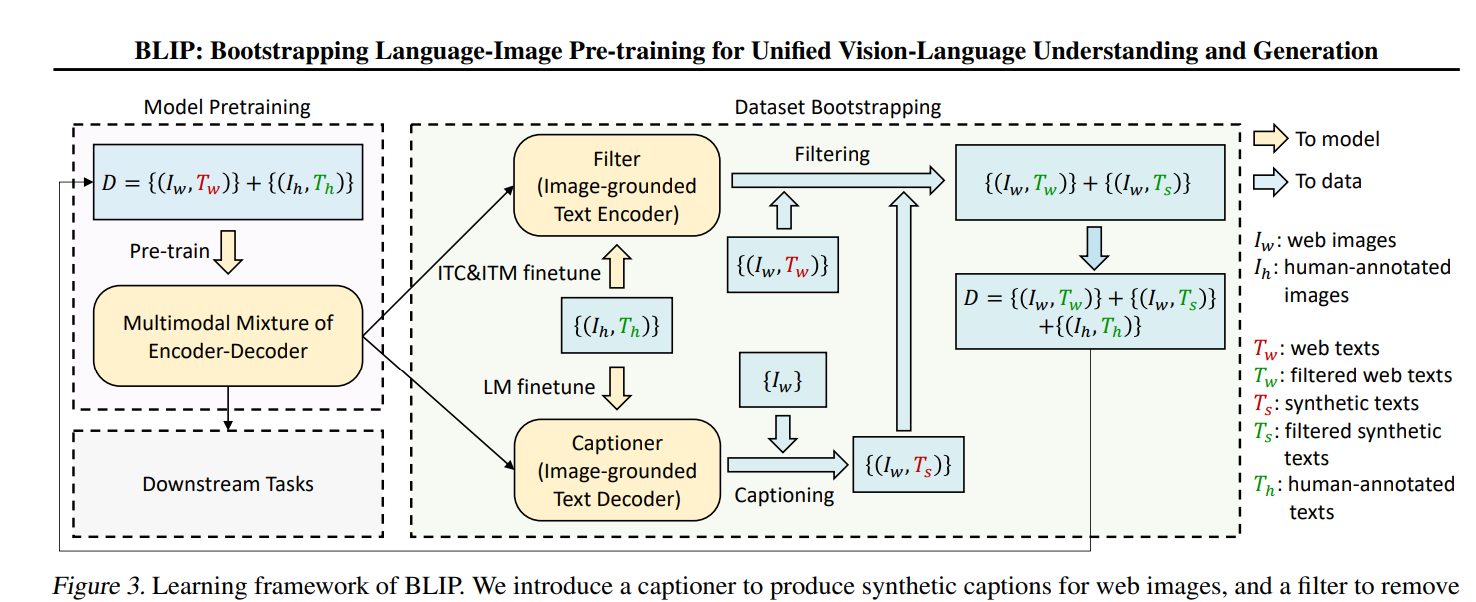

The diagram shows that ITC and ITM are chosen for making filter this makes sense as the aim of these loses is two capture how image and text go together.


1. Model Pretraining
   - A multimodal encoder-decoder is trained on a combined dataset .
   - Dataset **D** includes:
     - **Web images + web texts (w, T_w)
     - **Web images + human-annotated texts (w, T_h)
   - This enables BLIP to handle both **understanding tasks** (like retrieval, VQA) and generation tasks (like captioning).

2. Dataset Bootstrapping
   - Starts with noisy web image-text pairs.
   - **Filtering step**: Removes irrelevant or low-quality texts → produces cleaner pairs (w, T_w′).
   - **ITC & ITM fine-tuning**: Improves alignment between images and texts.
   - **Synthetic text generation**:
     - **T_s**: Generated by the ITC/ITM model.
     - **T_c**: Generated by a captioner (image-grounded decoder).
   - **Language model fine-tuning**: Uses human-annotated pairs (w, T_h).
   - Final dataset **D** is enriched with:
     - Filtered web texts (T_w′)
     - Synthetic texts (T_s)
     - Synthetic captions (T_c)
     - Human annotations (T_h)

---

- BLIP doesn’t just rely on raw web data—it bootstraps better supervision by filtering and generating new captions.
- This creates a **richer, cleaner, and more diverse training set , which boosts both  vision-language understanding and generation.
- The clever part is that BLIP uses its own models to improve its training data—like a self-improving loop.

---



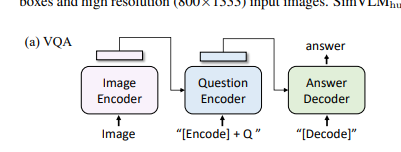

The image shows the part of blip model used for Visual question answering.

The paper mentions-

During finetuning, we rearrange the pre-trained model, where an image-question is first encoded into multimodal embeddings and then given to an answer decoder. The VQA model is finetuned with the LM loss
decoder. The VQA model is finetuned with the LM loss
using ground-truth answers as targets.